In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [10]:
df = pd.read_csv("iris.csv")
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['variety'] = le.fit_transform(df['variety'])

In [18]:
le = LabelEncoder()

df["variety"] = le.fit_transform(df["variety"])

df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [20]:
X = df.drop("variety", axis=1)
y = df["variety"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (112, 4)
Testing: (38, 4)


In [22]:
model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

In [23]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[2 1 0 2 0 2 0 1 1 1]


In [24]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13  0  0]
 [ 0 16  0]
 [ 0  0  9]]


In [25]:
TP = cm[1][1]

FP = cm[:,1].sum() - TP

FN = cm[1,:].sum() - TP

TN = cm.sum() - (TP + FP + FN)

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

TP: 16
FP: 0
TN: 22
FN: 0


In [26]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [27]:
error_rate = (FP + FN) / (TP + TN + FP + FN)

print("Error Rate:", error_rate)

Error Rate: 0.0


In [28]:
precision = TP / (TP + FP)

print("Precision:", precision)

Precision: 1.0


In [29]:
recall = TP / (TP + FN)

print("Recall:", recall)

Recall: 1.0


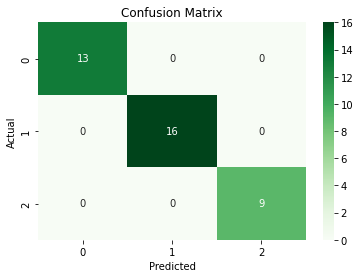

In [30]:
sns.heatmap(cm, annot=True, cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()